# Residue Environment Heatmap

**What this notebook does:**
- Reads pre-computed frequency tables describing how often each atom within 5 Å of
  **ASP25 Cα** appears across MD simulation frames (one CSV per simulation)
- Filters to **Cα atoms** of neighbouring residues (excluding ASP25 itself)
- Normalises atom identifiers across simulations (strips the atom index prefix that
  can vary between runs) to create consistent **descriptive labels**
- Builds a **heatmap** (residues × simulations) with interaction frequency as colour

**Prerequisites:**
Run `02_analysis_env25_heatmap.ipynb` (or equivalent) first to generate the frequency CSVs.

**This notebook is equivalent to `02_analysis_env25_heatmap.ipynb` but uses already calculated frequencies based on CSV files.**

**Sections:**
1. Imports
2. Configuration (paths, simulation names)
3. Load and parse frequency tables
4. Build heatmap matrix
5. Plot heatmap


In [91]:
# 1. Imports
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [92]:
# 2. Configuration
ROOTDIR    = '/content/drive/MyDrive/M1_STAGE/Manips/Tables/'
OUTPUT_FIG = '/content/drive/MyDrive/M1_STAGE/Manips/Figures/env25_heatmap.png'

SIMULATION_NAMES = ['V1', 'V11', 'V12', 'V7', 'V8', 'V21']

# Frequency CSV filenames (one per simulation)
FREQ_DF_PATHS = [
    'V1_ASP_env_atoms_frequency.csv',
    'V11_ASP_env_atoms_frequency.csv',
    'V12_ASP_env_atoms_frequency.csv',
    'V7_ASP_env_atoms_frequency.csv',
    'V8_ASP_env_atoms_frequency.csv',
    'V21_ASP_env_atoms_frequency.csv',
]

# Atom-index threshold: indices < CHAIN_BOUNDARY → chain A; >= → chain B
CHAIN_BOUNDARY = 1536

# The target residue label to exclude from neighbours
TARGET_LABEL = 'ASP_25'

os.chdir(ROOTDIR)

In [93]:
# 3. Load and parse frequency tables
all_results     = {}
all_atom_data   = []  # collected across sims for descriptive-label deduplication

for sim_path in FREQ_DF_PATHS:
    sim_name = sim_path.replace('_ASP_env_atoms_frequency.csv', '')
    df_sim   = pd.read_csv(sim_path)

    # Keep only Cα atoms; exclude the target residue itself
    filtered = df_sim[
        df_sim['Residue'].apply(lambda x: 'CA' in x and TARGET_LABEL not in x)
    ].copy()

    rows = []
    for atom in filtered['Residue'].values:
        parts      = atom.split('_')
        atom_idx   = int(parts[0])
        atom_name  = parts[1]
        res_type   = parts[2]
        res_num    = parts[3]
        chain_lbl  = 'chA' if atom_idx < CHAIN_BOUNDARY else 'chB'
        desc_label = f'{atom_name}_{res_type}{res_num}_{chain_lbl}'

        freq_val = float(filtered.loc[filtered['Residue'] == atom, 'Frequency'].iloc[0])
        rows.append({
            'Atom_Identifier': atom,
            'Frequency': freq_val,
            'Chain': chain_lbl,
            'Residue_Id': f'{res_type}{res_num}',
            'Descriptive_Label': desc_label
        })
        all_atom_data.append({
            'Atom_Identifier_Full': atom,
            'Atom_ID': atom_idx,
            'Descriptive_Label': desc_label,
            'Simulation': sim_name
        })

    all_results[sim_name] = pd.DataFrame(rows)

atom_data_df = pd.DataFrame(all_atom_data)
print(f'Loaded {len(all_results)} simulations, '
      f'{atom_data_df["Descriptive_Label"].nunique()} unique residue labels.')

Loaded 6 simulations, 25 unique residue labels.


In [94]:
# 4. Build heatmap matrix (simulations × residue descriptive labels)
all_residues = sorted(atom_data_df['Descriptive_Label'].unique())
heatmap_data = pd.DataFrame(0.0, index=SIMULATION_NAMES, columns=all_residues)

for sim_name, df_sim in all_results.items():
    merged = df_sim.groupby('Descriptive_Label')['Frequency'].max()
    for label, freq in merged.items():
        if label in heatmap_data.columns:
            heatmap_data.loc[sim_name, label] = freq

heatmap_data = heatmap_data.fillna(0.0)
# Sort columns alphabetically for consistent display
heatmap_data = heatmap_data.reindex(columns=sorted(heatmap_data.columns))
print(f'Heatmap matrix shape: {heatmap_data.shape}')

Heatmap matrix shape: (6, 25)


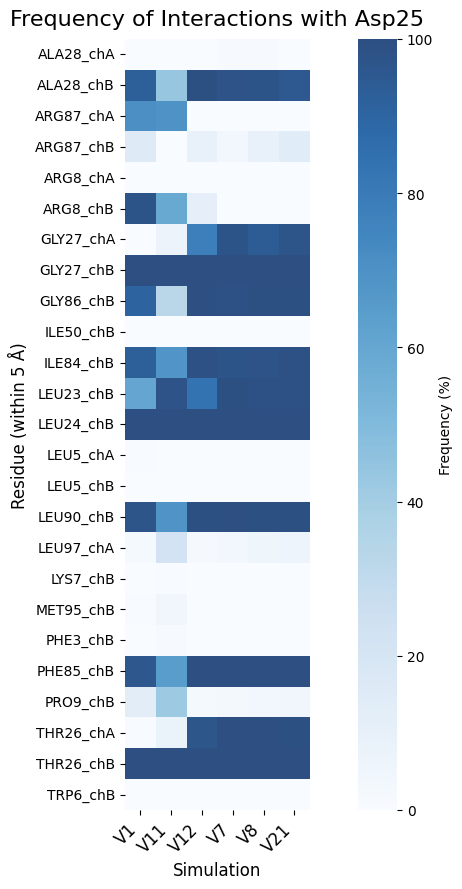

Saved to /content/drive/MyDrive/M1_STAGE/Manips/Figures/env25_heatmap.png


In [95]:
# 5. Plot heatmap
y_labels = [lbl.replace('CA_', '') for lbl in heatmap_data.columns]

fig, ax = plt.subplots(
    figsize=(max(10, len(all_residues) * 0.4), max(4, len(SIMULATION_NAMES) * 1.5))
)
sns.heatmap(
    heatmap_data.T,
    annot=False,
    cmap='Blues',
    square=True,
    alpha=0.85,
    cbar_kws={'label': 'Frequency (%)'},
    ax=ax
)
ax.set_title('Frequency of Interactions with Asp25', fontsize=16, pad=10)
ax.set_xlabel('Simulation', fontsize=12)
ax.set_ylabel('Residue (within 5 Å)', fontsize=12)
ax.set_yticklabels(y_labels, rotation=0, fontsize=10)
ax.set_xticklabels(SIMULATION_NAMES, rotation=45, ha='right', fontsize=12)
plt.tight_layout()
plt.show()

fig.savefig(OUTPUT_FIG, bbox_inches='tight', dpi=300)
print(f'Saved to {OUTPUT_FIG}')